# Baseline Experiment Findings — AgenticCyOps

**Purpose:** Visualize and analyze the baseline experiment results across 6 validator groups (A-F), 4 domains (cyberops, healthcare, finance, legal), and 3 configurations (flat, acl_hardened, agenticcyops).

**Data source:** `results/baseline/group_{A-F}/{domain}/enhanced_baseline.csv` (35+ columns per row, 3 rows per file)

## Section 1: Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Professional plot style
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.05, palette="muted")
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 140,
    "savefig.bbox": "tight",
    "font.family": "sans-serif",
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.figsize": (12, 6),
    "legend.fontsize": 10,
})

# ---------------------------------------------------------------------------
# Colour scheme
# ---------------------------------------------------------------------------
CONFIG_COLORS = {
    "flat": "#e74c3c",
    "acl_hardened": "#f39c12",
    "agenticcyops": "#2ecc71",
}
CONFIG_LABELS = {"flat": "Flat MAS", "acl_hardened": "ACL-Hardened", "agenticcyops": "AgenticCyOps"}
CONFIGS = ["flat", "acl_hardened", "agenticcyops"]
GROUPS = list("ABCDEF")
DOMAINS = ["cyberops", "healthcare", "finance", "legal"]
PHASES = ["monitor", "analyze", "admin", "report"]

# ---------------------------------------------------------------------------
# Tool manifests (from component_registry.json counts)
# ---------------------------------------------------------------------------
TOOL_MANIFEST = {
    "cyberops":   {"monitor": 4, "analyze": 3, "admin": 5, "report": 4, "total": 16},
    "healthcare": {"monitor": 4, "analyze": 3, "admin": 3, "report": 3, "total": 13},
    "finance":    {"monitor": 4, "analyze": 3, "admin": 3, "report": 3, "total": 13},
    "legal":      {"monitor": 4, "analyze": 3, "admin": 3, "report": 3, "total": 13},
}

# Utility: add value labels on bars
def _bar_labels(ax, bars, fmt="{:.0f}", fontsize=9, offset=0.3):
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + offset,
                    fmt.format(h), ha="center", va="bottom",
                    fontsize=fontsize, fontweight="bold")

print("Setup complete.")

Setup complete.


In [2]:
# ---------------------------------------------------------------------------
# Load all enhanced_baseline.csv files into a single DataFrame
# ---------------------------------------------------------------------------
BASE = Path("/storage/data/AgenticCyOps_Private")
frames = []
for g in GROUPS:
    for d in DOMAINS:
        csv_path = BASE / "results" / "baseline" / f"group_{g}" / d / "enhanced_baseline.csv"
        if csv_path.exists():
            tmp = pd.read_csv(csv_path)
            frames.append(tmp)
        else:
            print(f"  [skip] {csv_path.relative_to(BASE)} not found")

df = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(df)} rows  x  {len(df.columns)} columns  "
      f"({df['group'].nunique()} groups, {df['domain'].nunique()} domains, "
      f"{df['config'].nunique()} configs)")
df.head(6)

Loaded 72 rows  x  62 columns  (6 groups, 4 domains, 3 configs)


,config,domain,group,total_events,phases_completed,tool_calls_total,tool_calls_allowed,tool_calls_denied,tools_visible_per_agent,p1_identity_checks,...,p5_fp_rate,total_fp_rate,e2e_latency_s,avg_tool_latency_ms,consensus_avg_latency_ms,total_tokens,tokens_prompt,tokens_completion,memory_reads,memory_writes
0,flat,cyberops,A,30,4,19,19,0,16.0,0,...,0.0,0.0000,30.97,5.15,0.00,16418,15351,1067,0,4
1,acl_hardened,cyberops,A,30,4,19,10,9,16.0,0,...,0.0,0.0000,55.58,5.84,0.00,17479,15751,1728,0,4
2,agenticcyops,cyberops,A,107,4,11,11,0,4.0,11,...,0.0,0.0000,161.42,5.23,4673.72,10147,8193,1954,7,4
3,flat,healthcare,A,25,4,13,13,0,13.0,0,...,0.0,0.0000,26.55,4.49,0.00,15097,14258,839,0,5
4,acl_hardened,healthcare,A,26,4,14,8,6,13.0,0,...,0.0,0.0000,25.45,5.78,0.00,15261,14445,816,0,5
5,agenticcyops,healthcare,A,171,4,14,12,2,3.2,15,...,0.0,0.1429,253.12,5.43,5603.82,9363,8244,1119,5,5


## Section 2: Configuration Comparison Overview

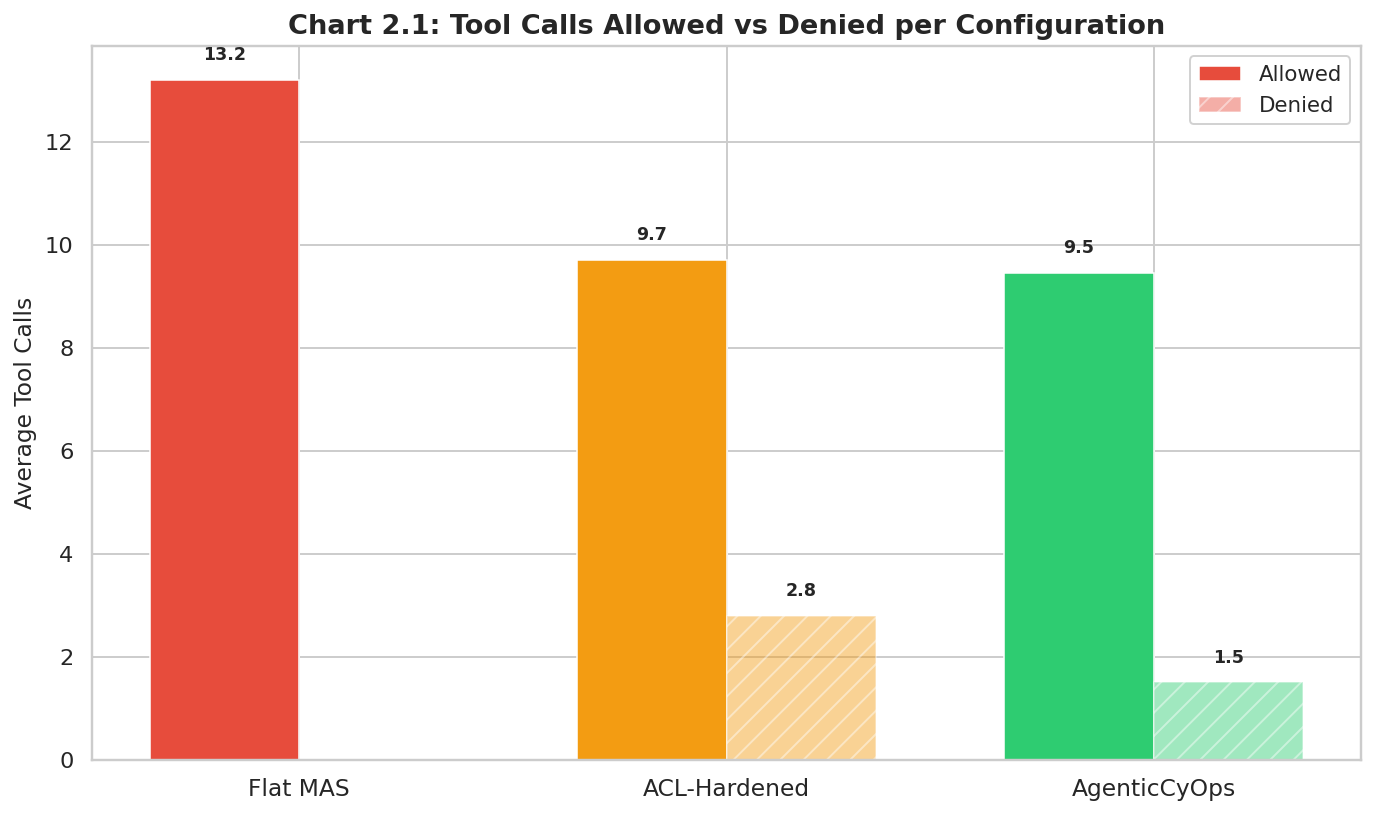

In [3]:
# Chart 2.1: Grouped bar — Tool calls allowed vs denied per config
# (averaged across all groups and domains)

agg = df.groupby("config")[["tool_calls_allowed", "tool_calls_denied"]].mean().reindex(CONFIGS)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(CONFIGS))
w = 0.35

bars1 = ax.bar(x - w/2, agg["tool_calls_allowed"], w,
               label="Allowed", color=[CONFIG_COLORS[c] for c in CONFIGS],
               edgecolor="white", linewidth=0.8)
bars2 = ax.bar(x + w/2, agg["tool_calls_denied"], w,
               label="Denied", color=[CONFIG_COLORS[c] for c in CONFIGS],
               edgecolor="white", linewidth=0.8, alpha=0.45, hatch="//")

_bar_labels(ax, bars1, fmt="{:.1f}")
_bar_labels(ax, bars2, fmt="{:.1f}")

ax.set_xticks(x)
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=12)
ax.set_ylabel("Average Tool Calls")
ax.set_title("Chart 2.1: Tool Calls Allowed vs Denied per Configuration",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9, fontsize=11)
plt.tight_layout()
plt.show()

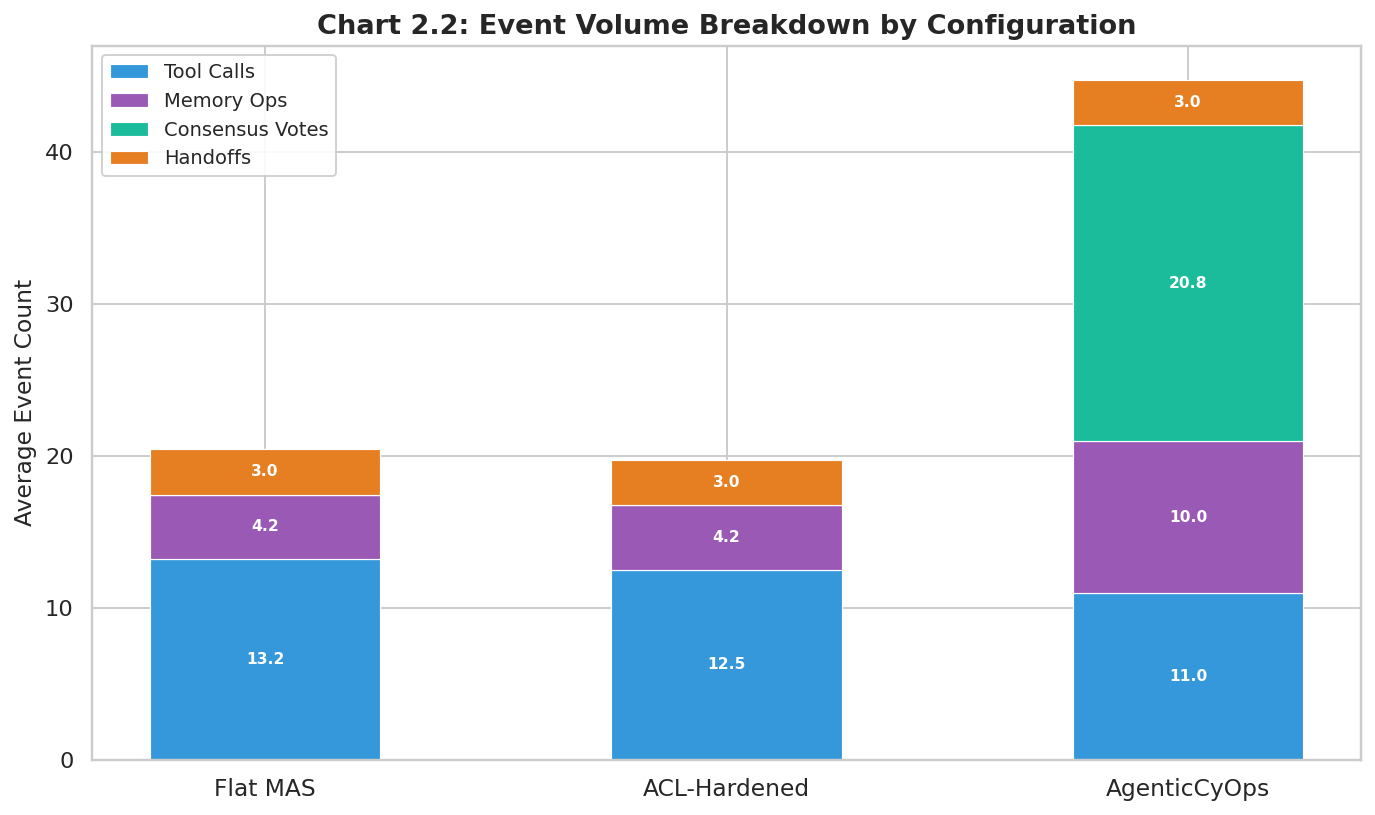

In [4]:
# Chart 2.2: Stacked bar — Event volume breakdown by config
# Categories: tool_calls_total, memory ops (reads+writes), consensus votes, handoffs (phases-1)

breakdown = df.groupby("config").agg(
    tool_calls=("tool_calls_total", "mean"),
    memory_ops=("memory_reads", lambda s: (s + df.loc[s.index, "memory_writes"]).mean()),
    consensus=("p3_consensus_votes", "mean"),
).reindex(CONFIGS)

# Approximate handoffs as phases_completed - 1 (inter-phase transitions)
handoffs_mean = df.groupby("config")["phases_completed"].mean().reindex(CONFIGS).apply(lambda x: max(x - 1, 0))
breakdown["handoffs"] = handoffs_mean

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(CONFIGS))
w = 0.5
categories = ["tool_calls", "memory_ops", "consensus", "handoffs"]
cat_colors = ["#3498db", "#9b59b6", "#1abc9c", "#e67e22"]
cat_labels = ["Tool Calls", "Memory Ops", "Consensus Votes", "Handoffs"]

bottom = np.zeros(len(CONFIGS))
for cat, color, label in zip(categories, cat_colors, cat_labels):
    vals = breakdown[cat].values
    bars = ax.bar(x, vals, w, bottom=bottom, label=label, color=color,
                  edgecolor="white", linewidth=0.6)
    # Label each segment if tall enough
    for i, (b, v) in enumerate(zip(bottom, vals)):
        if v > 0.8:
            ax.text(x[i], b + v / 2, f"{v:.1f}", ha="center", va="center",
                    fontsize=8, fontweight="bold", color="white")
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=12)
ax.set_ylabel("Average Event Count")
ax.set_title("Chart 2.2: Event Volume Breakdown by Configuration",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

In [5]:
# Table 2.1: Summary stats per config
summary = df.groupby("config").agg(
    avg_events=("total_events", "mean"),
    avg_allowed=("tool_calls_allowed", "mean"),
    avg_denied=("tool_calls_denied", "mean"),
    avg_latency_s=("e2e_latency_s", "mean"),
    avg_tokens=("total_tokens", "mean"),
).reindex(CONFIGS)
summary.index = [CONFIG_LABELS[c] for c in CONFIGS]
summary = summary.round(2)
print("Table 2.1: Summary Statistics per Configuration")
print("=" * 70)
display(summary)

Table 2.1: Summary Statistics per Configuration


,avg_events,avg_allowed,avg_denied,avg_latency_s,avg_tokens
Flat MAS,24.46,13.21,0.00,61.10,16561.38
ACL-Hardened,23.75,9.71,2.79,62.41,16911.29
AgenticCyOps,119.75,9.46,1.50,213.36,10839.83


## Section 3: Principle Activity Across Configs

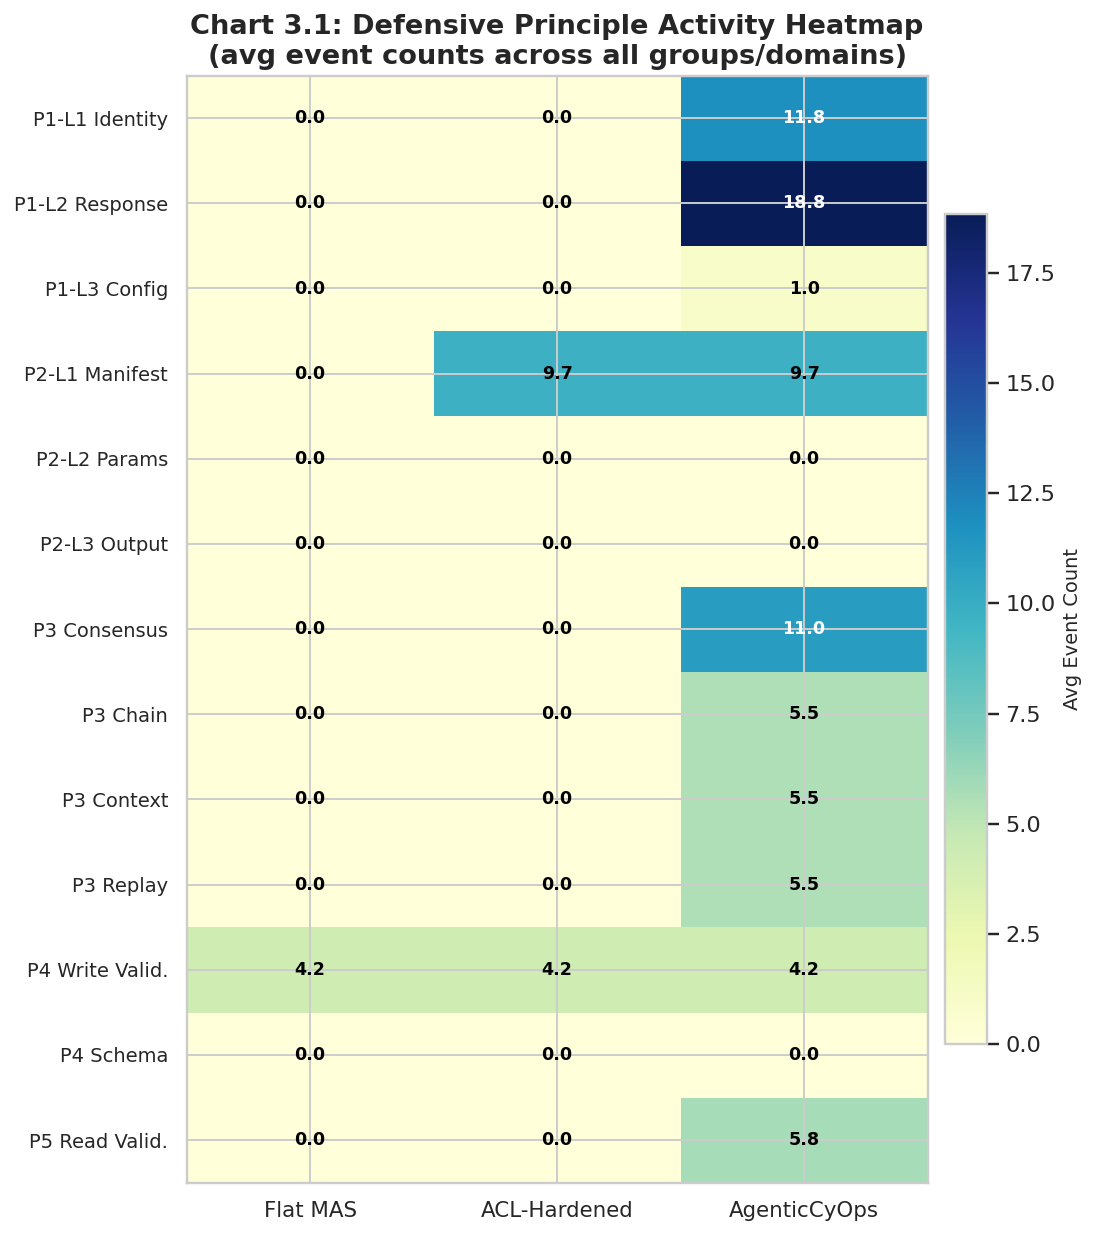

In [6]:
# Chart 3.1: Heatmap — principle layers x configs, values = avg event counts
HEATMAP_ROWS = {
    "P1-L1 Identity":   ["p1_identity_checks"],
    "P1-L2 Response":   ["p1_response_checks"],
    "P1-L3 Config":     ["p1_config_checks"],
    "P2-L1 Manifest":   ["p2_manifest_checks"],
    "P2-L2 Params":     ["p2_parameter_checks"],
    "P2-L3 Output":     ["p2_output_checks"],
    "P3 Consensus":     ["p3_total_validations"],
    "P3 Chain":         ["p3_chain_events"],
    "P3 Context":       ["p3_operational_events"],
    "P3 Replay":        ["p3_replay_events"],
    "P4 Write Valid.":  ["p4_write_validations"],
    "P4 Schema":        ["p4_schema_checks"],
    "P5 Read Valid.":   ["p5_read_validations"],
}

heat_data = np.zeros((len(HEATMAP_ROWS), len(CONFIGS)))
for j, cfg in enumerate(CONFIGS):
    subset = df[df["config"] == cfg]
    for i, (label, cols) in enumerate(HEATMAP_ROWS.items()):
        heat_data[i, j] = subset[cols].sum(axis=1).mean()

fig, ax = plt.subplots(figsize=(8, 9))
im = ax.imshow(heat_data, aspect="auto", cmap="YlGnBu", interpolation="nearest")

ax.set_xticks(range(len(CONFIGS)))
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=11)
ax.set_yticks(range(len(HEATMAP_ROWS)))
ax.set_yticklabels(list(HEATMAP_ROWS.keys()), fontsize=10)

# Annotate cells
for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        val = heat_data[i, j]
        color = "white" if val > heat_data.max() * 0.55 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=9, fontweight="bold", color=color)

ax.set_title("Chart 3.1: Defensive Principle Activity Heatmap\n(avg event counts across all groups/domains)",
             fontsize=14, fontweight="bold")
cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Avg Event Count", fontsize=10)
plt.tight_layout()
plt.show()

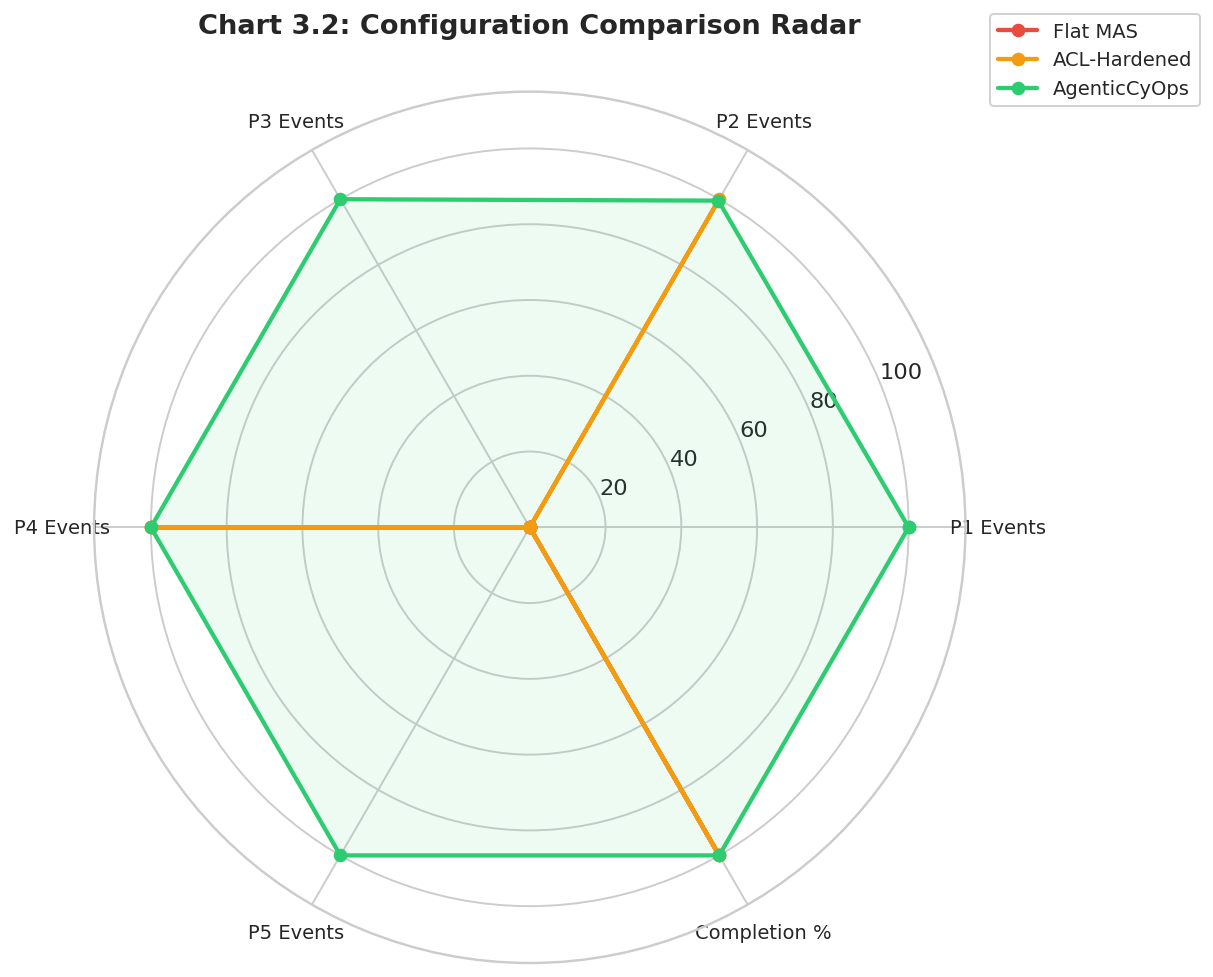

In [7]:
# Chart 3.2: Radar/spider chart — 6 axes x 3 configs
# Axes: P1 events, P2 events, P3 events, P4 events, P5 events, completion rate

def _principle_total(sub, pnum):
    """Sum all mechanism columns for a principle."""
    p_cols = {
        1: ["p1_identity_checks", "p1_response_checks", "p1_config_checks"],
        2: ["p2_manifest_checks", "p2_parameter_checks", "p2_output_checks"],
        3: ["p3_total_validations", "p3_chain_events", "p3_operational_events", "p3_replay_events"],
        4: ["p4_write_validations", "p4_schema_checks", "p4_metadata_checks"],
        5: ["p5_read_validations", "p5_field_filter_events", "p5_query_scope_events", "p5_sanitization_events"],
    }
    existing = [c for c in p_cols[pnum] if c in sub.columns]
    return sub[existing].sum(axis=1).mean() if existing else 0

radar_labels = ["P1 Events", "P2 Events", "P3 Events", "P4 Events", "P5 Events", "Completion %"]
n_axes = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False).tolist()
angles += angles[:1]

raw_vals = {}
for cfg in CONFIGS:
    sub = df[df["config"] == cfg]
    vals = [_principle_total(sub, p) for p in range(1, 6)]
    vals.append(sub["phases_completed"].mean() / 4 * 100)
    raw_vals[cfg] = vals

# Normalize to 0-100
max_per_axis = [max(raw_vals[c][i] for c in CONFIGS) for i in range(n_axes)]
max_per_axis = [v if v > 0 else 1 for v in max_per_axis]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
for cfg in CONFIGS:
    normed = [v / m * 100 for v, m in zip(raw_vals[cfg], max_per_axis)]
    normed += normed[:1]
    ax.plot(angles, normed, "o-", linewidth=2.2, label=CONFIG_LABELS[cfg],
            color=CONFIG_COLORS[cfg], markersize=6)
    ax.fill(angles, normed, alpha=0.08, color=CONFIG_COLORS[cfg])

ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=10)
ax.set_ylim(0, 115)
ax.set_title("Chart 3.2: Configuration Comparison Radar",
             fontsize=14, fontweight="bold", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.1), frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

## Section 4: Attack Surface Reduction

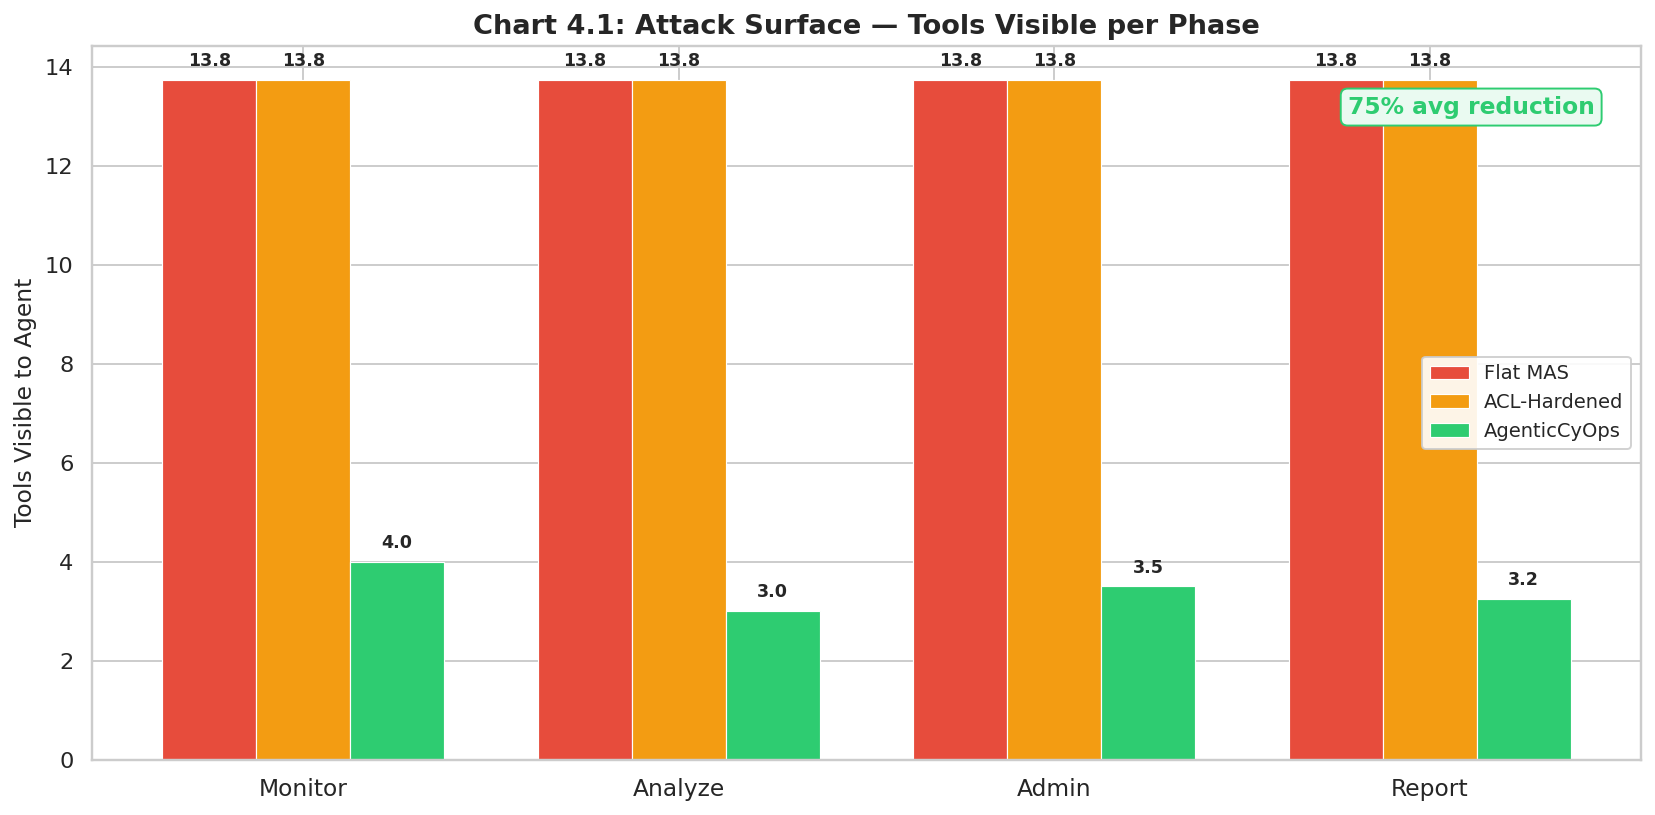

In [8]:
# Chart 4.1: Grouped bar — Tools visible per phase per config (averaged across domains)
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(PHASES))
w = 0.25

for i, cfg in enumerate(CONFIGS):
    vals = []
    for phase in PHASES:
        if cfg == "agenticcyops":
            # Average manifest tools across domains for this phase
            vals.append(np.mean([TOOL_MANIFEST[d].get(phase, 0) for d in DOMAINS]))
        else:
            # Flat/ACL see ALL tools for the domain (average across domains)
            vals.append(np.mean([TOOL_MANIFEST[d]["total"] for d in DOMAINS]))
    bars = ax.bar(x + i * w, vals, w, label=CONFIG_LABELS[cfg],
                  color=CONFIG_COLORS[cfg], edgecolor="white", linewidth=0.6)
    _bar_labels(ax, bars, fmt="{:.1f}", offset=0.2)

ax.set_xticks(x + w)
ax.set_xticklabels([p.title() for p in PHASES], fontsize=12)
ax.set_ylabel("Tools Visible to Agent")
ax.set_title("Chart 4.1: Attack Surface — Tools Visible per Phase",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9)

# Annotation: average reduction
avg_flat = np.mean([TOOL_MANIFEST[d]["total"] for d in DOMAINS])
avg_aco = np.mean([np.mean([TOOL_MANIFEST[d].get(p, 0) for d in DOMAINS]) for p in PHASES])
reduction_pct = (1 - avg_aco / avg_flat) * 100
ax.text(0.97, 0.93, f"{reduction_pct:.0f}% avg reduction",
        transform=ax.transAxes, ha="right", va="top", fontsize=12,
        color=CONFIG_COLORS["agenticcyops"], fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#eafaf1",
                  edgecolor=CONFIG_COLORS["agenticcyops"]))

plt.tight_layout()
plt.show()

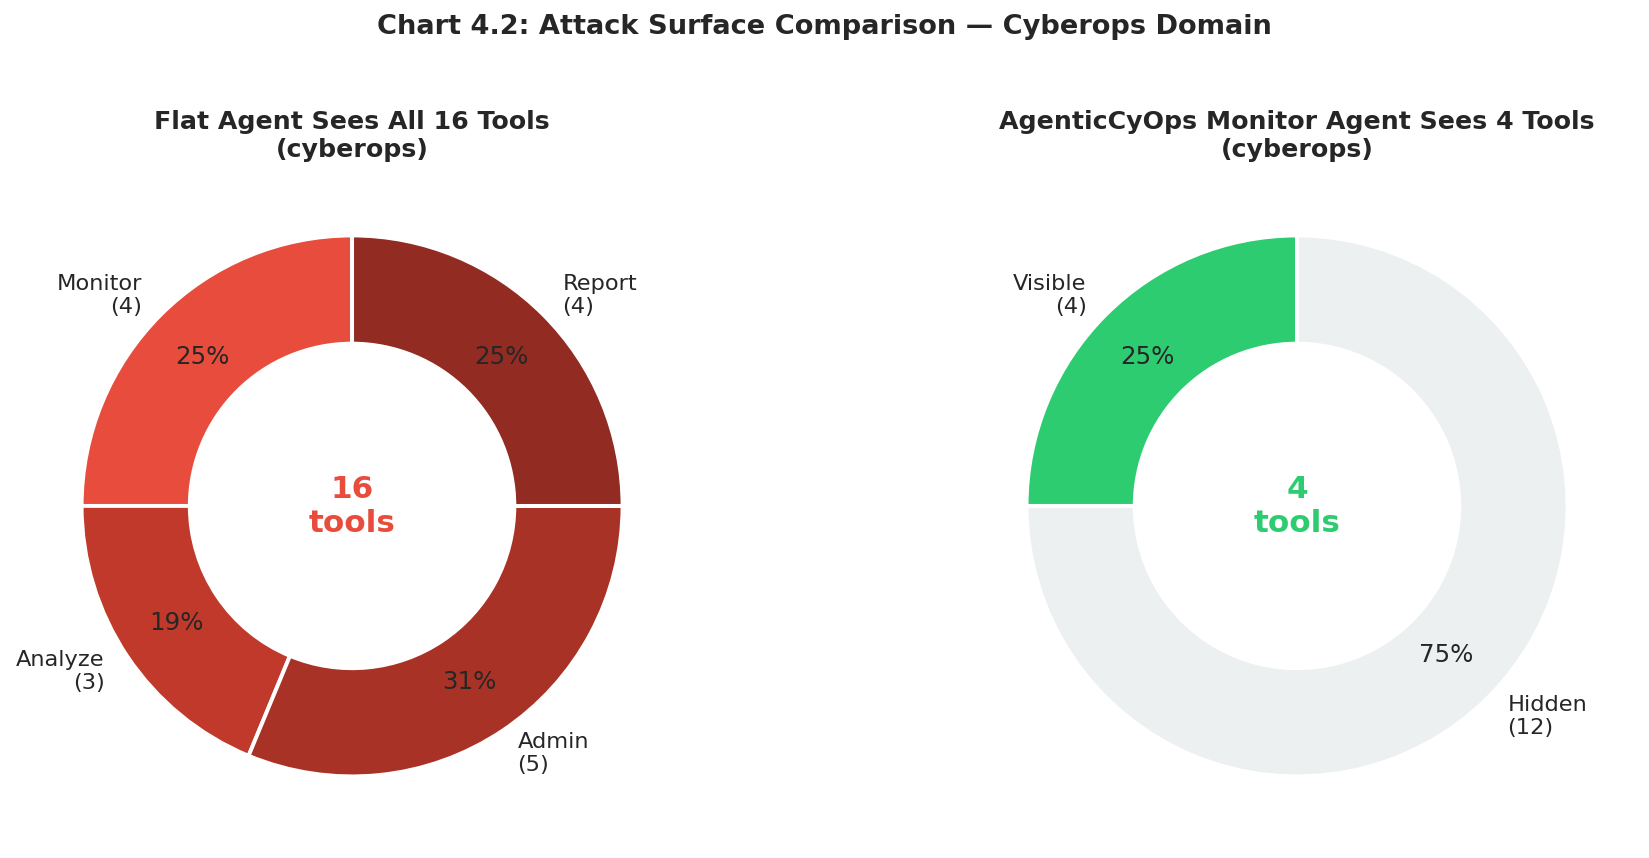

In [9]:
# Chart 4.2: Donut chart pair — Flat agent sees ALL tools vs AgenticCyOps sees manifest tools
# Using cyberops as the showcase domain

domain_ex = "cyberops"
total_flat = TOOL_MANIFEST[domain_ex]["total"]
manifest_monitor = TOOL_MANIFEST[domain_ex]["monitor"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left donut: Flat agent (all 16 tools visible)
phase_vals_flat = [TOOL_MANIFEST[domain_ex][p] for p in PHASES]
phase_labels_flat = [f"{p.title()}\n({v})" for p, v in zip(PHASES, phase_vals_flat)]
colors_flat = ["#e74c3c", "#c0392b", "#a93226", "#922b21"]
wedges1, texts1, autotexts1 = ax1.pie(
    phase_vals_flat, labels=phase_labels_flat, autopct="%1.0f%%",
    colors=colors_flat, startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2))
ax1.set_title(f"Flat Agent Sees All {total_flat} Tools\n(cyberops)", fontsize=13, fontweight="bold")
centre1 = plt.Circle((0, 0), 0.55, fc="white")
ax1.add_artist(centre1)
ax1.text(0, 0, f"{total_flat}\ntools", ha="center", va="center", fontsize=16, fontweight="bold",
         color="#e74c3c")

# Right donut: AgenticCyOps monitor agent sees only monitor-phase tools
other_phases = total_flat - manifest_monitor
sizes = [manifest_monitor, other_phases]
labels_aco = [f"Visible\n({manifest_monitor})", f"Hidden\n({other_phases})"]
colors_aco = ["#2ecc71", "#ecf0f1"]
wedges2, texts2, autotexts2 = ax2.pie(
    sizes, labels=labels_aco, autopct="%1.0f%%",
    colors=colors_aco, startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=2))
ax2.set_title(f"AgenticCyOps Monitor Agent Sees {manifest_monitor} Tools\n(cyberops)",
              fontsize=13, fontweight="bold")
centre2 = plt.Circle((0, 0), 0.55, fc="white")
ax2.add_artist(centre2)
ax2.text(0, 0, f"{manifest_monitor}\ntools", ha="center", va="center", fontsize=16, fontweight="bold",
         color="#2ecc71")

fig.suptitle("Chart 4.2: Attack Surface Comparison — Cyberops Domain",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## Section 5: False Positive Analysis

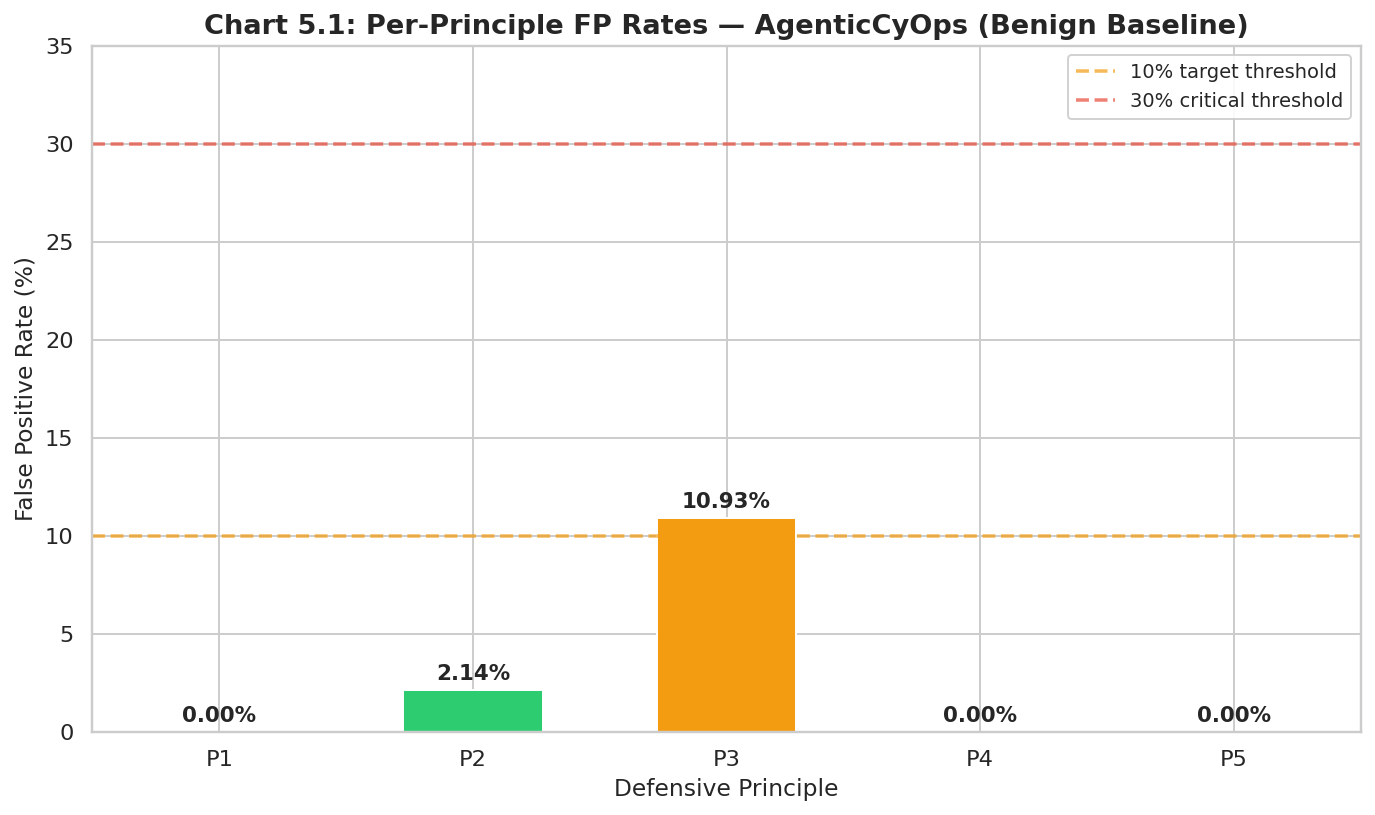

In [10]:
# Chart 5.1: Per-principle FP rate bar chart for agenticcyops with threshold lines
aco = df[df["config"] == "agenticcyops"]
principles = ["P1", "P2", "P3", "P4", "P5"]
fp_means = [aco[f"p{i}_fp_rate"].mean() * 100 for i in range(1, 6)]

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if r > 30 else "#f39c12" if r > 10 else "#2ecc71" for r in fp_means]
bars = ax.bar(principles, fp_means, color=colors, edgecolor="white", linewidth=1, width=0.55)

# Threshold lines
ax.axhline(y=10, color="#f39c12", linestyle="--", linewidth=1.8, alpha=0.7, label="10% target threshold")
ax.axhline(y=30, color="#e74c3c", linestyle="--", linewidth=1.8, alpha=0.7, label="30% critical threshold")

for bar, r in zip(bars, fp_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{r:.2f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_xlabel("Defensive Principle", fontsize=12)
ax.set_ylabel("False Positive Rate (%)", fontsize=12)
ax.set_title("Chart 5.1: Per-Principle FP Rates — AgenticCyOps (Benign Baseline)",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper right", frameon=True, framealpha=0.9, fontsize=10)
ax.set_ylim(0, max(max(fp_means) * 1.4, 35))
plt.tight_layout()
plt.show()

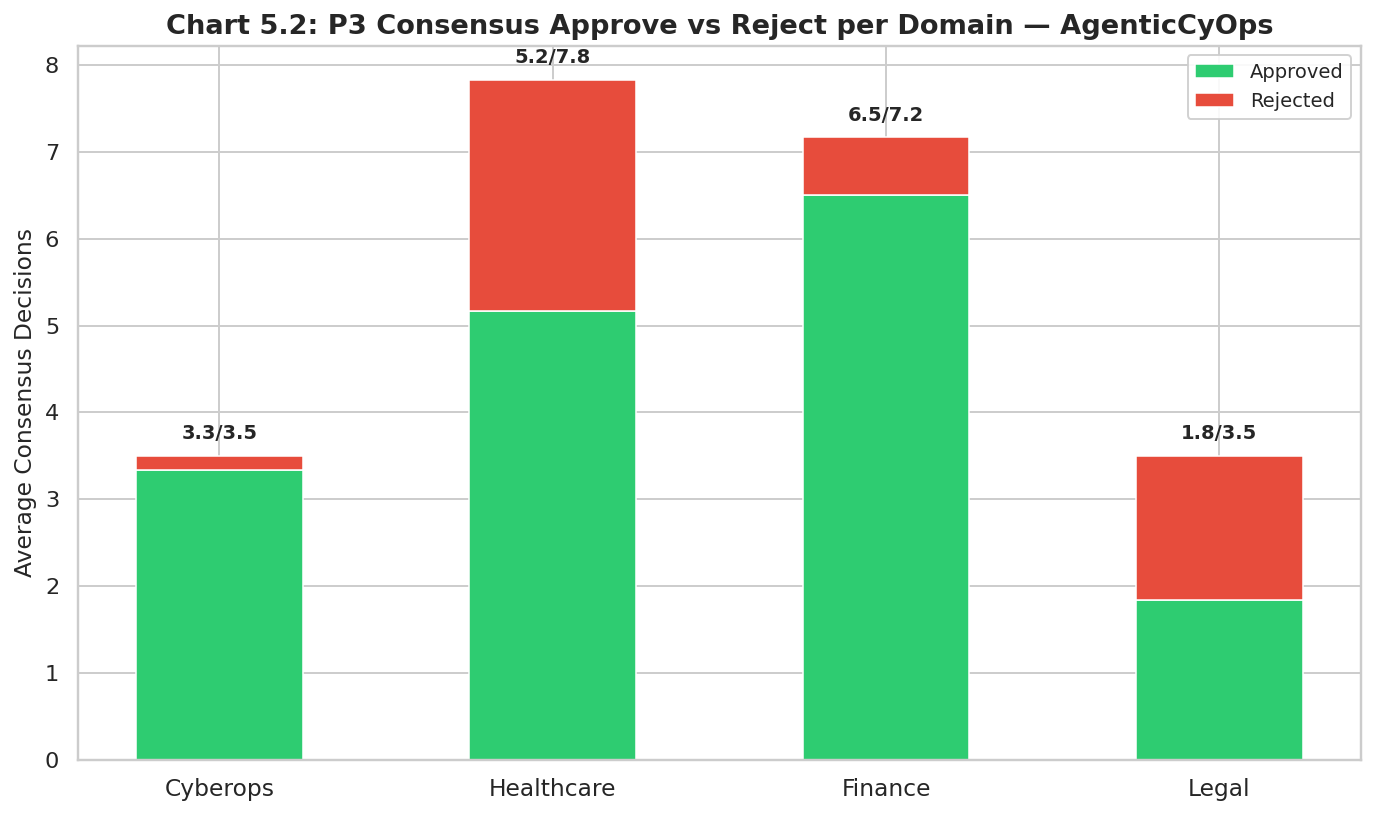

In [11]:
# Chart 5.2: Consensus rejection analysis — stacked bar per domain (agenticcyops)
aco = df[df["config"] == "agenticcyops"]
cons_agg = aco.groupby("domain")[["p3_approved", "p3_rejected"]].mean().reindex(DOMAINS)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(DOMAINS))
w = 0.5

bars_a = ax.bar(x, cons_agg["p3_approved"], w, label="Approved", color="#2ecc71",
                edgecolor="white", linewidth=0.8)
bars_r = ax.bar(x, cons_agg["p3_rejected"], w, bottom=cons_agg["p3_approved"],
                label="Rejected", color="#e74c3c", edgecolor="white", linewidth=0.8)

# Labels
for i in range(len(DOMAINS)):
    total = cons_agg["p3_approved"].iloc[i] + cons_agg["p3_rejected"].iloc[i]
    if total > 0:
        ax.text(x[i], total + 0.15, f"{cons_agg['p3_approved'].iloc[i]:.1f}/{total:.1f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels([d.title() for d in DOMAINS], fontsize=12)
ax.set_ylabel("Average Consensus Decisions")
ax.set_title("Chart 5.2: P3 Consensus Approve vs Reject per Domain — AgenticCyOps",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

In [12]:
# Table 5.1: FP rates per domain per group for agenticcyops
aco = df[df["config"] == "agenticcyops"].copy()
aco["total_fp_pct"] = aco["total_fp_rate"] * 100

fp_pivot = aco.pivot_table(
    index="group", columns="domain", values="total_fp_pct", aggfunc="mean"
).reindex(index=GROUPS, columns=DOMAINS)
fp_pivot.columns = [d.title() for d in DOMAINS]

# Add row mean
fp_pivot["Mean"] = fp_pivot.mean(axis=1)
# Add column mean
fp_pivot.loc["Mean"] = fp_pivot.mean(axis=0)

print("Table 5.1: Total FP Rate (%) per Group x Domain — AgenticCyOps")
print("=" * 65)
display(fp_pivot.round(2).style.format("{:.2f}%").background_gradient(cmap="RdYlGn_r", vmin=0, vmax=30))

Table 5.1: Total FP Rate (%) per Group x Domain — AgenticCyOps


,Cyberops,Healthcare,Finance,Legal,Mean
group,,,,,
A,0.00%,14.29%,8.33%,25.00%,11.90%
B,0.00%,30.00%,22.22%,10.00%,15.56%
C,0.00%,7.14%,0.00%,8.33%,3.87%
D,37.50%,31.58%,10.00%,22.22%,25.32%
E,0.00%,21.43%,8.33%,25.00%,13.69%
F,0.00%,22.22%,10.00%,0.00%,8.06%
Mean,6.25%,21.11%,9.81%,15.09%,13.07%


## Section 6: Latency & Token Overhead

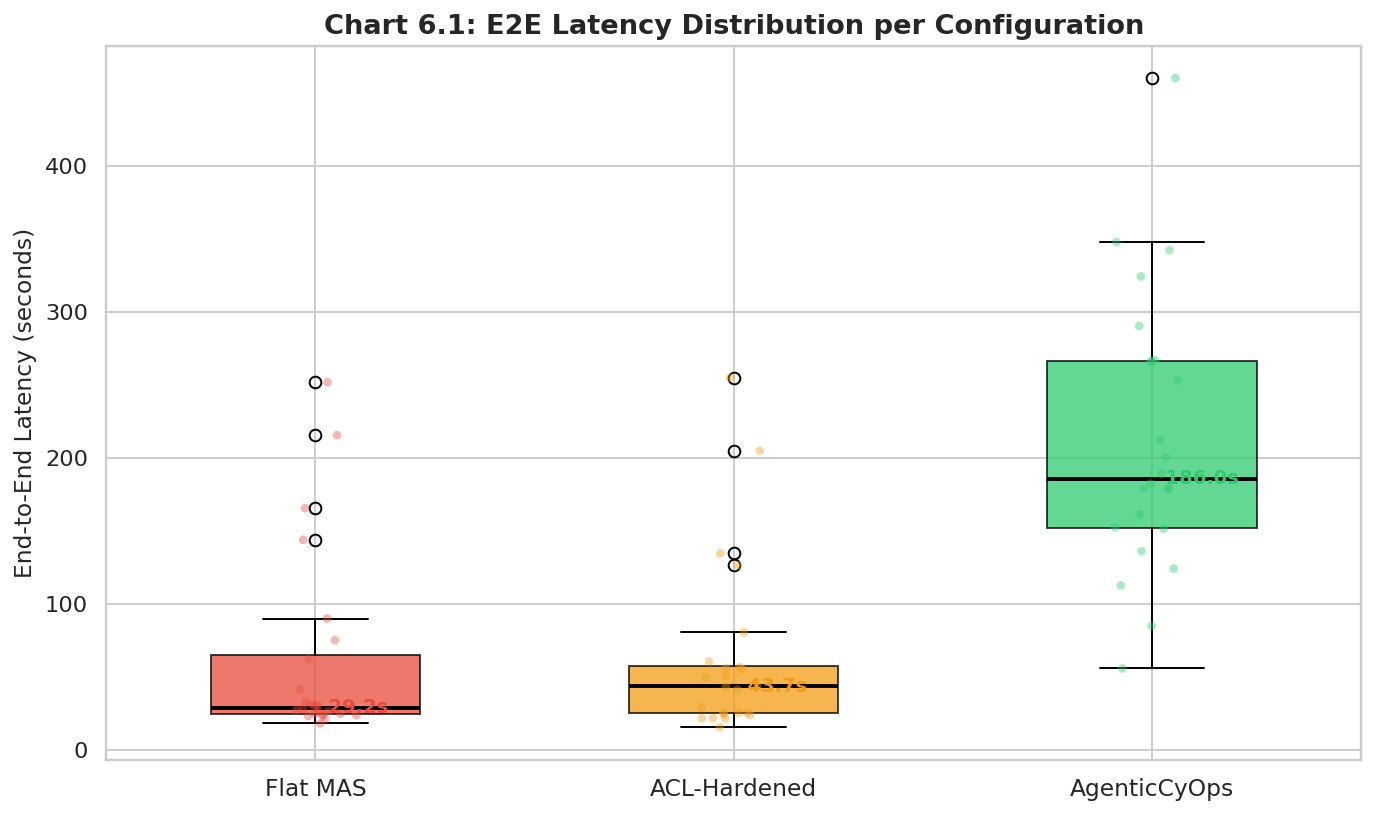

In [13]:
# Chart 6.1: Box plot — E2E latency per config across all groups/domains
fig, ax = plt.subplots(figsize=(10, 6))

box_data = [df[df["config"] == cfg]["e2e_latency_s"].dropna().values for cfg in CONFIGS]
bp = ax.boxplot(box_data, patch_artist=True, widths=0.5,
                medianprops=dict(color="black", linewidth=2))

for patch, cfg in zip(bp["boxes"], CONFIGS):
    patch.set_facecolor(CONFIG_COLORS[cfg])
    patch.set_alpha(0.75)
    patch.set_edgecolor("black")

# Overlay individual points
for i, cfg in enumerate(CONFIGS):
    vals = df[df["config"] == cfg]["e2e_latency_s"].dropna().values
    jitter = np.random.normal(0, 0.04, len(vals))
    ax.scatter(np.full_like(vals, i + 1) + jitter, vals,
               alpha=0.4, s=20, color=CONFIG_COLORS[cfg], zorder=3, edgecolor="none")

ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=12)
ax.set_ylabel("End-to-End Latency (seconds)")
ax.set_title("Chart 6.1: E2E Latency Distribution per Configuration",
             fontsize=14, fontweight="bold")

# Annotate medians
for i, cfg in enumerate(CONFIGS):
    med = df[df["config"] == cfg]["e2e_latency_s"].median()
    ax.text(i + 1, med, f"  {med:.1f}s", va="center", ha="left",
            fontsize=10, fontweight="bold", color=CONFIG_COLORS[cfg])

plt.tight_layout()
plt.show()

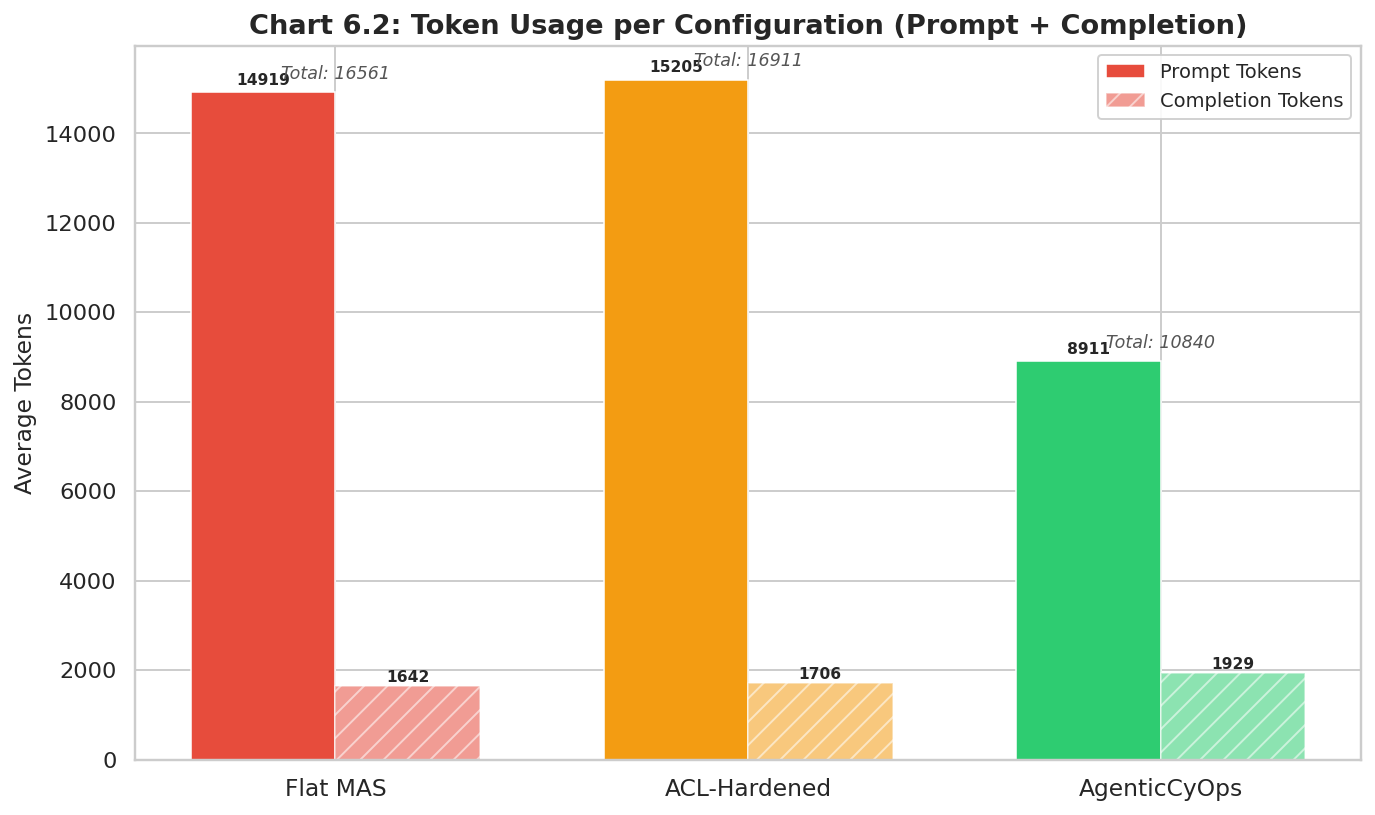

In [14]:
# Chart 6.2: Grouped bar — Token usage (prompt + completion) per config
token_agg = df.groupby("config")[["tokens_prompt", "tokens_completion"]].mean().reindex(CONFIGS)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(CONFIGS))
w = 0.35

bars_p = ax.bar(x - w/2, token_agg["tokens_prompt"], w, label="Prompt Tokens",
                color=[CONFIG_COLORS[c] for c in CONFIGS], edgecolor="white", linewidth=0.8)
bars_c = ax.bar(x + w/2, token_agg["tokens_completion"], w, label="Completion Tokens",
                color=[CONFIG_COLORS[c] for c in CONFIGS], edgecolor="white", linewidth=0.8,
                alpha=0.55, hatch="//")

_bar_labels(ax, bars_p, fmt="{:.0f}", fontsize=8, offset=100)
_bar_labels(ax, bars_c, fmt="{:.0f}", fontsize=8, offset=30)

ax.set_xticks(x)
ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=12)
ax.set_ylabel("Average Tokens")
ax.set_title("Chart 6.2: Token Usage per Configuration (Prompt + Completion)",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9)

# Annotate total
for i, cfg in enumerate(CONFIGS):
    total = token_agg.loc[cfg].sum()
    ax.text(x[i], token_agg.loc[cfg, "tokens_prompt"] + 300,
            f"Total: {total:.0f}", ha="center", fontsize=9, fontstyle="italic", color="#555")

plt.tight_layout()
plt.show()

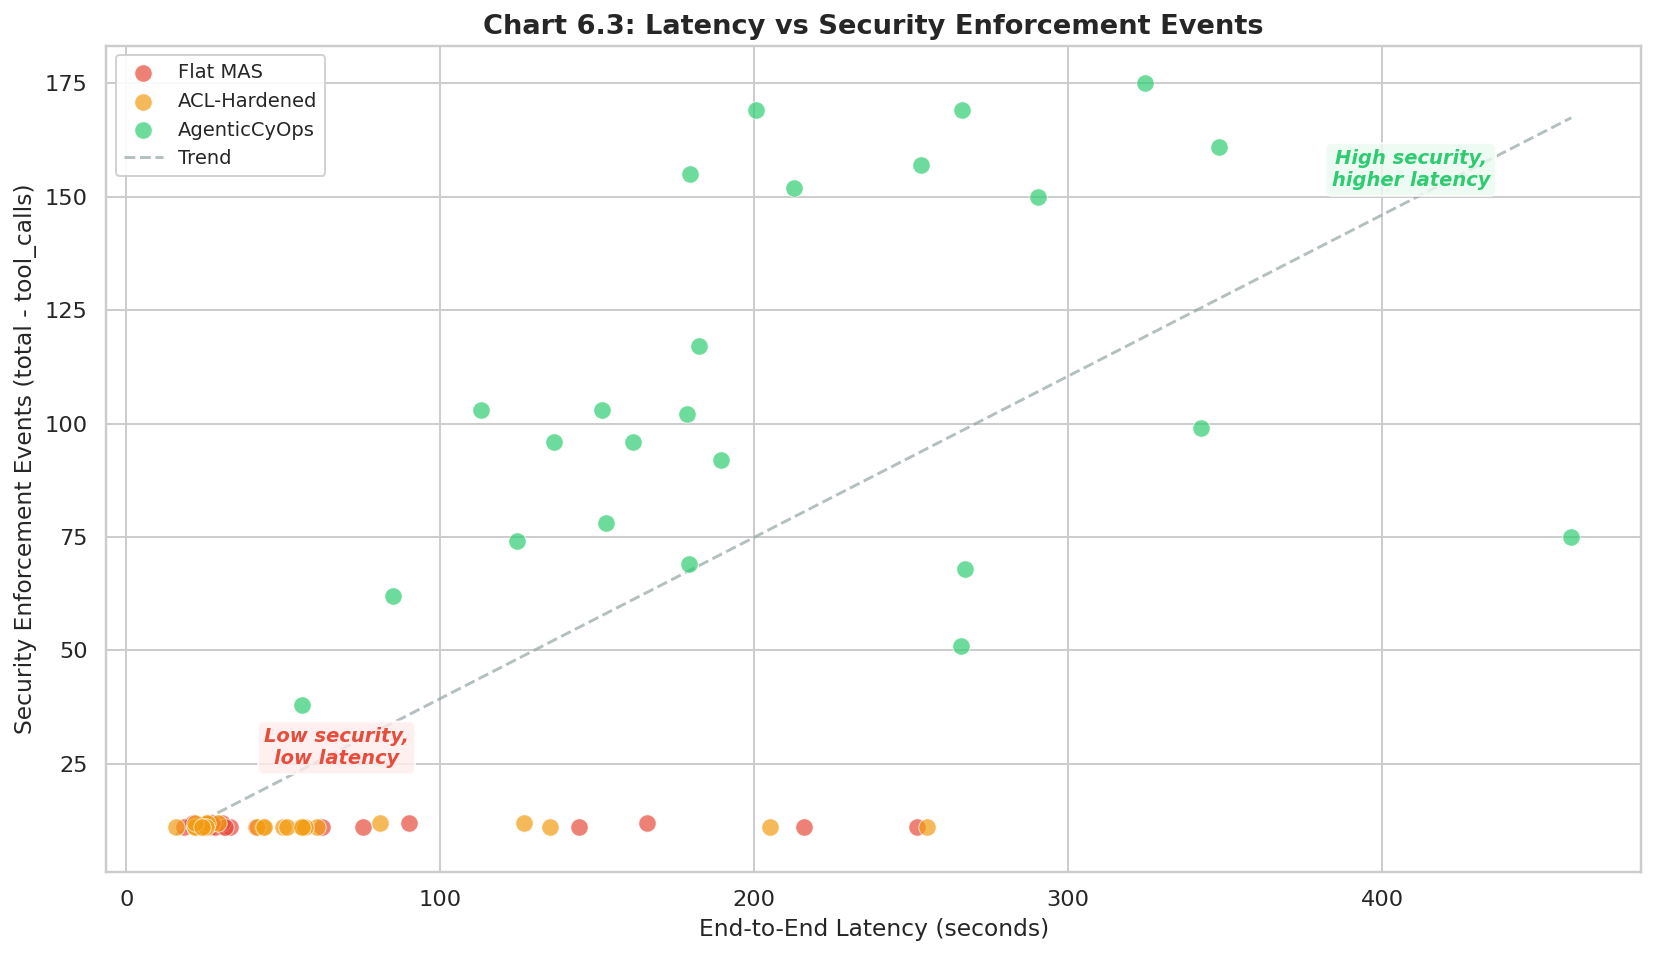

In [15]:
# Chart 6.3: Scatter — Latency vs total security events
# Shows that more enforcement = more latency but better security coverage
fig, ax = plt.subplots(figsize=(12, 7))

for cfg in CONFIGS:
    sub = df[df["config"] == cfg]
    # Security events = total_events - tool_calls_total (enforcement overhead)
    security_events = sub["total_events"] - sub["tool_calls_total"]
    ax.scatter(sub["e2e_latency_s"], security_events,
               color=CONFIG_COLORS[cfg], label=CONFIG_LABELS[cfg],
               s=80, alpha=0.7, edgecolors="white", linewidth=0.5, zorder=3)

# Trend line across all points
all_latency = df["e2e_latency_s"].values
all_security = (df["total_events"] - df["tool_calls_total"]).values
mask = np.isfinite(all_latency) & np.isfinite(all_security)
if mask.sum() > 2:
    z = np.polyfit(all_latency[mask], all_security[mask], 1)
    p = np.poly1d(z)
    x_line = np.linspace(all_latency[mask].min(), all_latency[mask].max(), 100)
    ax.plot(x_line, p(x_line), "--", color="#95a5a6", linewidth=1.5, alpha=0.7, label="Trend")

ax.set_xlabel("End-to-End Latency (seconds)", fontsize=12)
ax.set_ylabel("Security Enforcement Events (total - tool_calls)", fontsize=12)
ax.set_title("Chart 6.3: Latency vs Security Enforcement Events",
             fontsize=14, fontweight="bold")
ax.legend(frameon=True, framealpha=0.9, fontsize=10)

# Annotate regions
ax.annotate("High security,\nhigher latency", xy=(0.85, 0.85), xycoords="axes fraction",
            fontsize=10, fontstyle="italic", color="#2ecc71", fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#eafaf1", alpha=0.8))
ax.annotate("Low security,\nlow latency", xy=(0.15, 0.15), xycoords="axes fraction",
            fontsize=10, fontstyle="italic", color="#e74c3c", fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#fdedec", alpha=0.8))

plt.tight_layout()
plt.show()

## Section 7: Cross-Domain Consistency

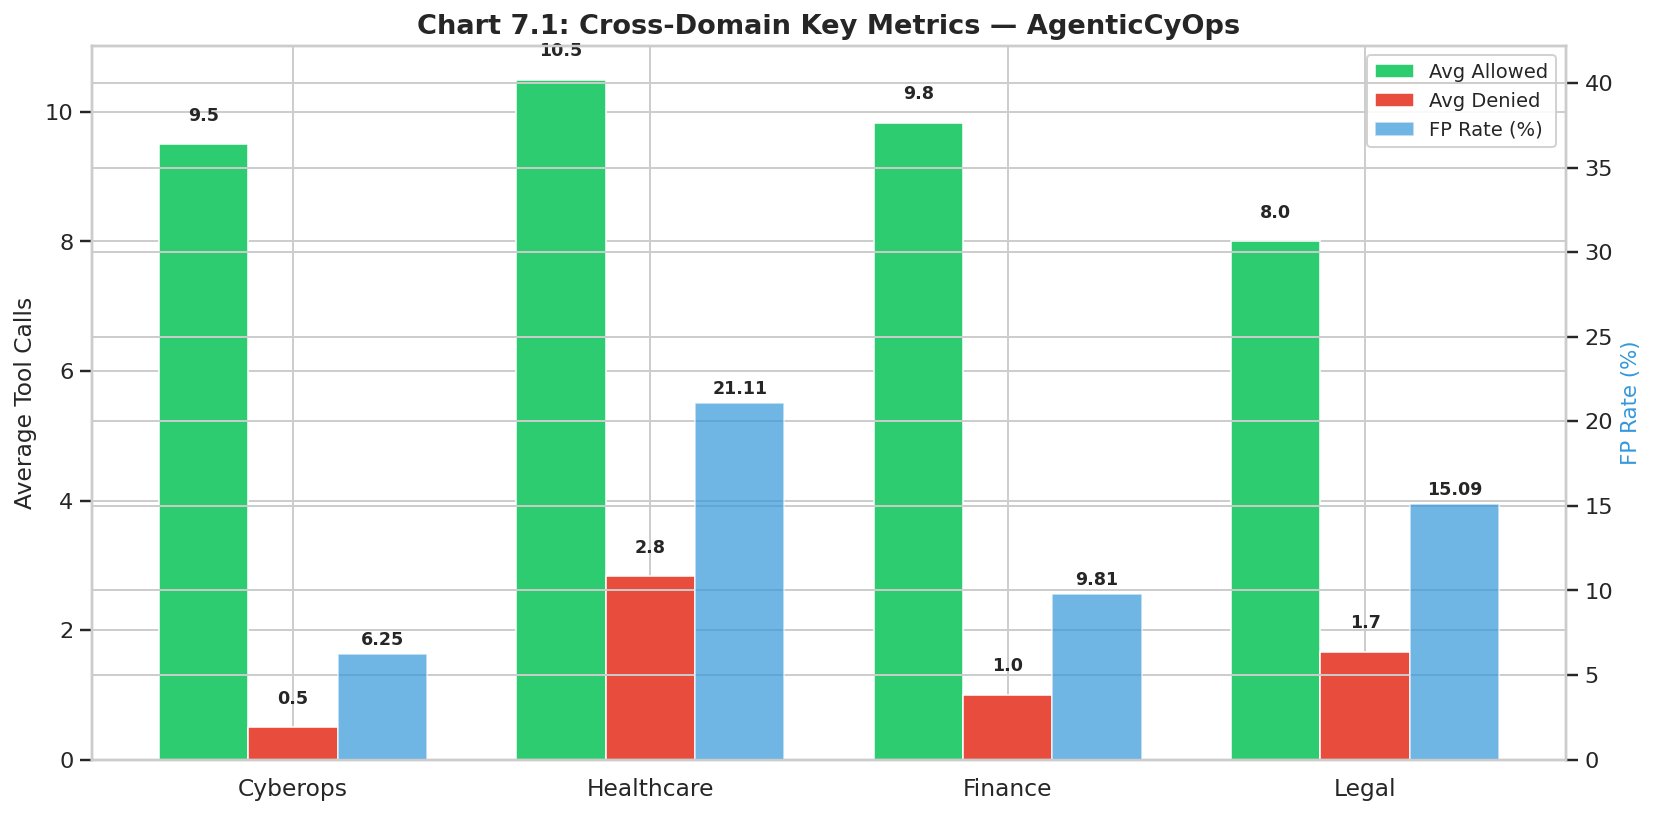

In [16]:
# Chart 7.1: Grouped bar — Key metrics per domain for agenticcyops
aco = df[df["config"] == "agenticcyops"]
dom_agg = aco.groupby("domain").agg(
    allowed=("tool_calls_allowed", "mean"),
    denied=("tool_calls_denied", "mean"),
    fp_rate=("total_fp_rate", lambda s: s.mean() * 100),
).reindex(DOMAINS)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(DOMAINS))
w = 0.25

bars1 = ax.bar(x - w, dom_agg["allowed"], w, label="Avg Allowed", color="#2ecc71",
               edgecolor="white", linewidth=0.8)
bars2 = ax.bar(x, dom_agg["denied"], w, label="Avg Denied", color="#e74c3c",
               edgecolor="white", linewidth=0.8)

# FP rate on secondary axis
ax2 = ax.twinx()
bars3 = ax2.bar(x + w, dom_agg["fp_rate"], w, label="FP Rate (%)", color="#3498db",
                edgecolor="white", linewidth=0.8, alpha=0.7)
ax2.set_ylabel("FP Rate (%)", fontsize=11, color="#3498db")
ax2.set_ylim(0, max(dom_agg["fp_rate"].max() * 2, 20))

_bar_labels(ax, bars1, fmt="{:.1f}")
_bar_labels(ax, bars2, fmt="{:.1f}")
_bar_labels(ax2, bars3, fmt="{:.2f}")

ax.set_xticks(x)
ax.set_xticklabels([d.title() for d in DOMAINS], fontsize=12)
ax.set_ylabel("Average Tool Calls")
ax.set_title("Chart 7.1: Cross-Domain Key Metrics — AgenticCyOps",
             fontsize=14, fontweight="bold")

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", frameon=True, framealpha=0.9)

plt.tight_layout()
plt.show()

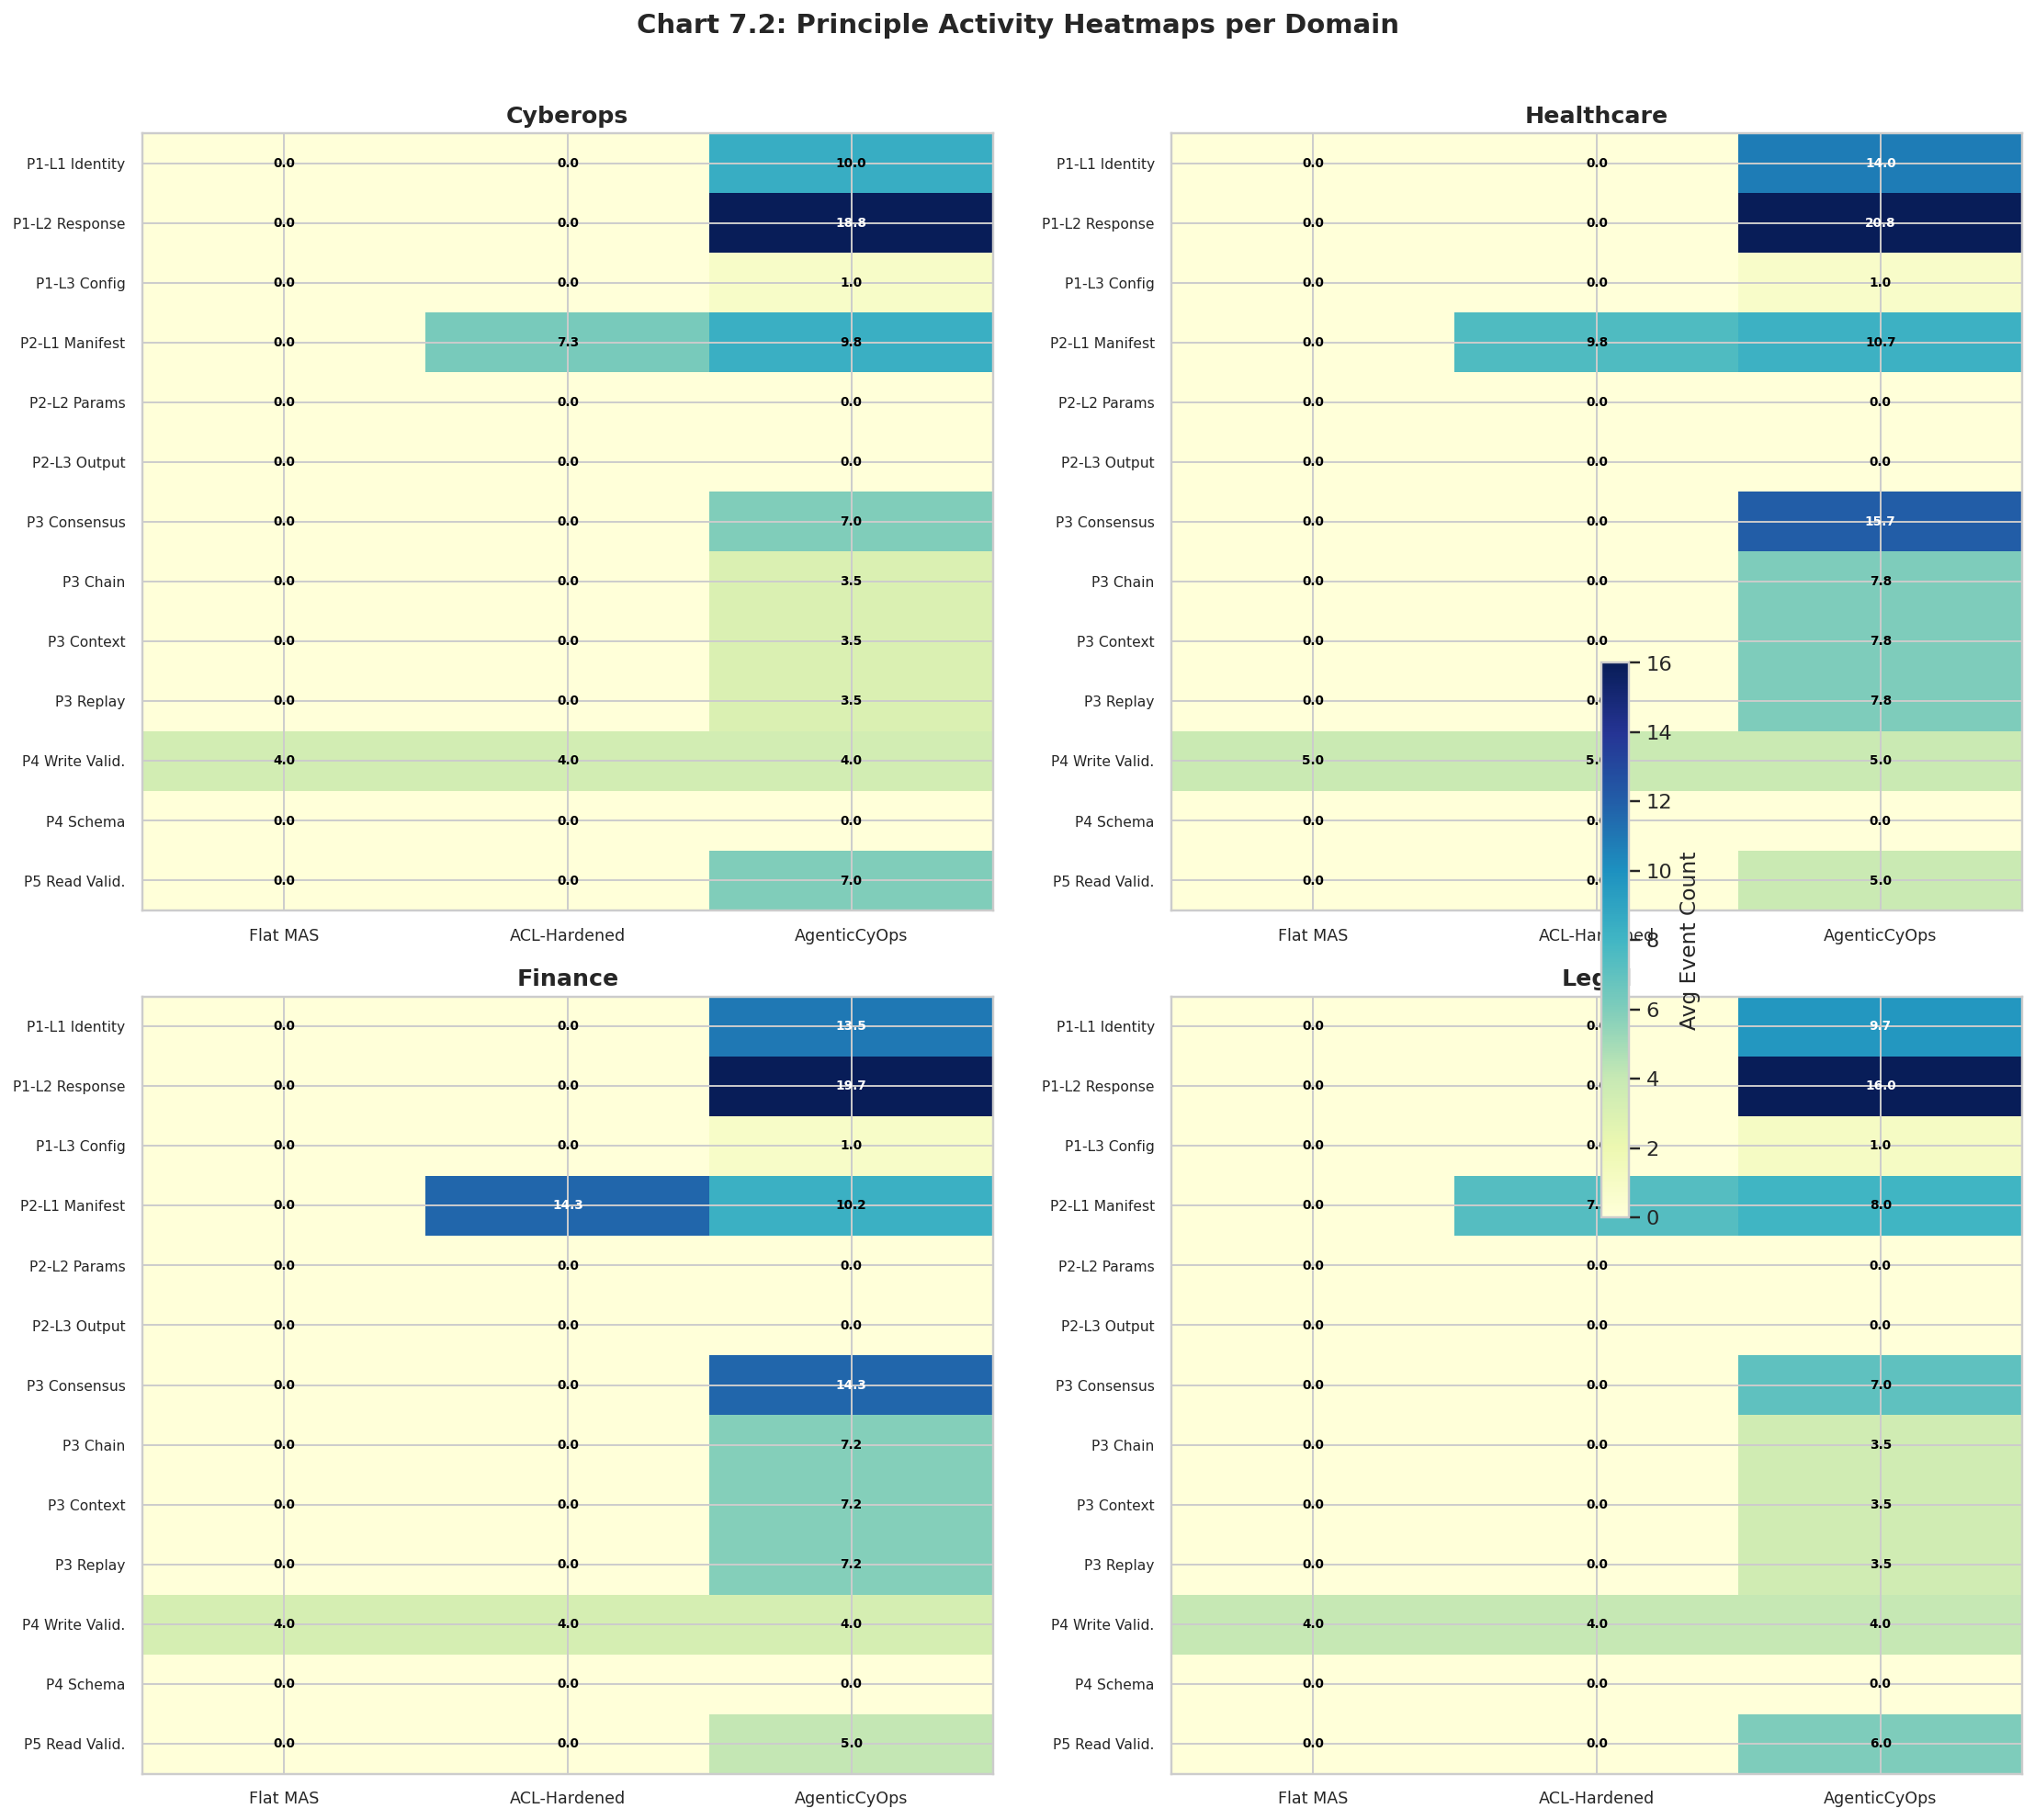

In [17]:
# Chart 7.2: Small multiples — 4 panels (one per domain) showing principle activity heatmaps
# Each panel: principle layers (rows) x configs (columns) for agenticcyops only average across groups

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for idx, domain in enumerate(DOMAINS):
    ax = axes_flat[idx]
    dom_df = df[df["domain"] == domain]

    heat = np.zeros((len(HEATMAP_ROWS), len(CONFIGS)))
    for j, cfg in enumerate(CONFIGS):
        subset = dom_df[dom_df["config"] == cfg]
        for i, (label, cols) in enumerate(HEATMAP_ROWS.items()):
            heat[i, j] = subset[cols].sum(axis=1).mean()

    im = ax.imshow(heat, aspect="auto", cmap="YlGnBu", interpolation="nearest")
    ax.set_xticks(range(len(CONFIGS)))
    ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIGS], fontsize=9)
    ax.set_yticks(range(len(HEATMAP_ROWS)))
    ax.set_yticklabels(list(HEATMAP_ROWS.keys()), fontsize=8)

    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            val = heat[i, j]
            color = "white" if val > heat.max() * 0.55 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    fontsize=7, fontweight="bold", color=color)

    ax.set_title(f"{domain.title()}", fontsize=13, fontweight="bold")

fig.suptitle("Chart 7.2: Principle Activity Heatmaps per Domain",
             fontsize=15, fontweight="bold", y=1.01)
fig.colorbar(im, ax=axes_flat, shrink=0.4, pad=0.02, label="Avg Event Count")
plt.tight_layout()
plt.show()

## Section 8: Cross-Group Validator Diversity

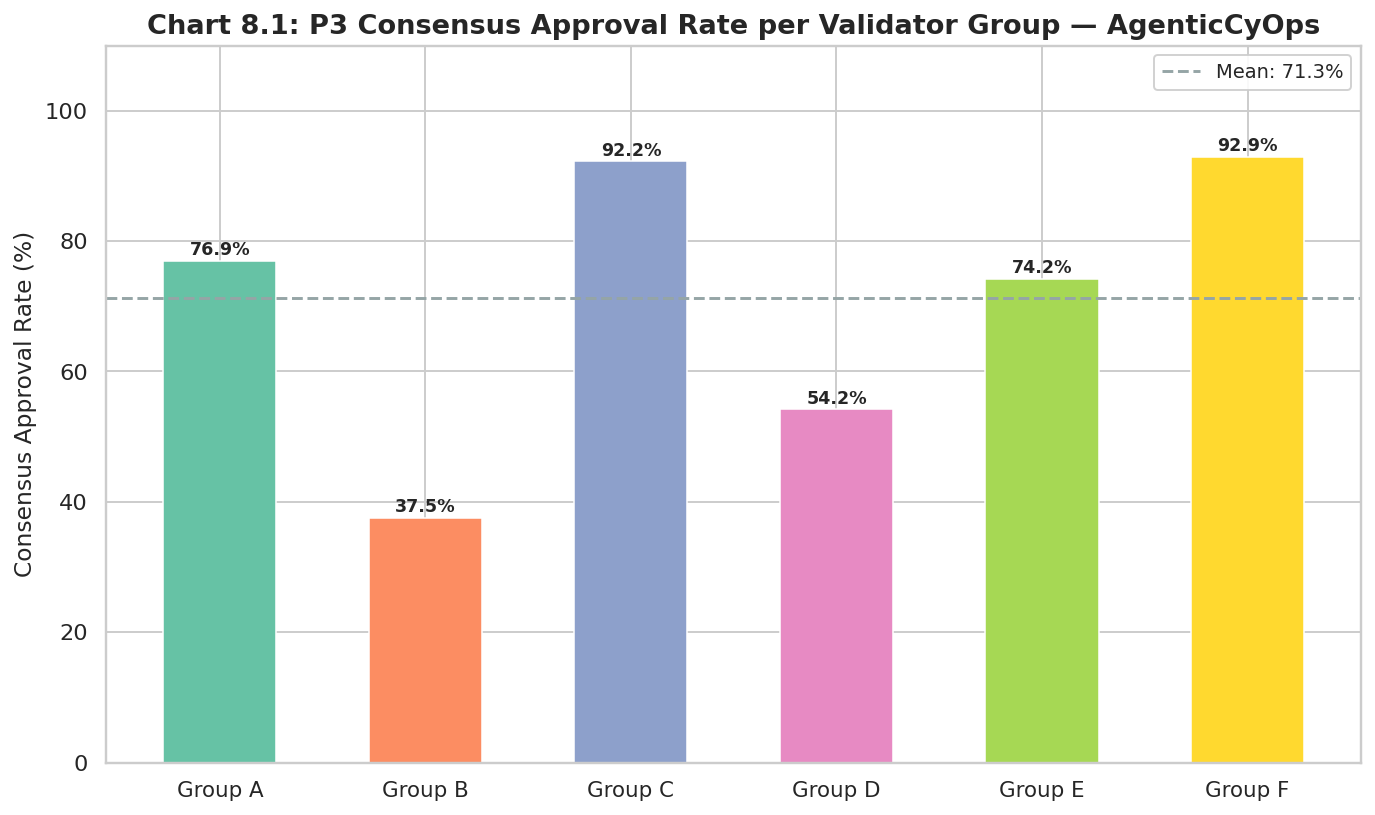

In [18]:
# Chart 8.1: Grouped bar — Consensus approval rate per group (A-F) for agenticcyops
aco = df[df["config"] == "agenticcyops"].copy()
aco["total_consensus"] = aco["p3_approved"] + aco["p3_rejected"]
aco["approval_rate"] = aco.apply(
    lambda r: r["p3_approved"] / r["total_consensus"] * 100 if r["total_consensus"] > 0 else 100, axis=1
)

group_approval = aco.groupby("group")["approval_rate"].mean().reindex(GROUPS)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(GROUPS))
palette = sns.color_palette("Set2", len(GROUPS))
bars = ax.bar(x, group_approval.values, 0.55, color=palette, edgecolor="white", linewidth=0.8)
_bar_labels(ax, bars, fmt="{:.1f}%")

ax.set_xticks(x)
ax.set_xticklabels([f"Group {g}" for g in GROUPS], fontsize=11)
ax.set_ylabel("Consensus Approval Rate (%)")
ax.set_title("Chart 8.1: P3 Consensus Approval Rate per Validator Group — AgenticCyOps",
             fontsize=14, fontweight="bold")
ax.set_ylim(0, 110)
ax.axhline(y=group_approval.mean(), color="#95a5a6", linestyle="--", linewidth=1.5,
           label=f"Mean: {group_approval.mean():.1f}%")
ax.legend(frameon=True, framealpha=0.9)
plt.tight_layout()
plt.show()

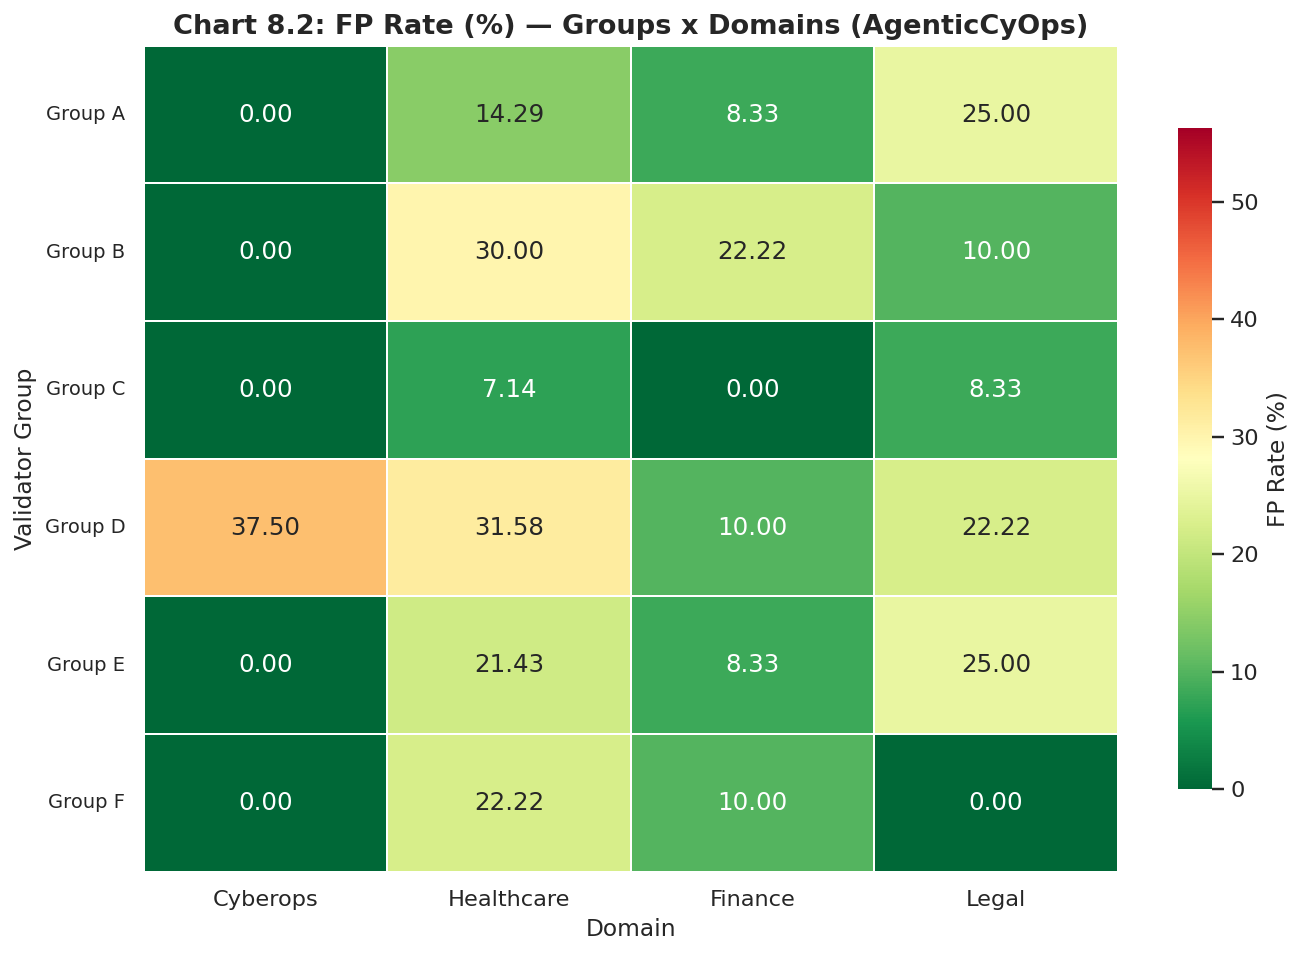

In [19]:
# Chart 8.2: Heatmap — Groups x domains showing FP rates for agenticcyops
aco = df[df["config"] == "agenticcyops"].copy()
aco["fp_pct"] = aco["total_fp_rate"] * 100

pivot = aco.pivot_table(index="group", columns="domain", values="fp_pct",
                        aggfunc="mean").reindex(index=GROUPS, columns=DOMAINS)
pivot.columns = [d.title() for d in DOMAINS]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", linewidths=1, linecolor="white",
            ax=ax, vmin=0, vmax=max(pivot.max().max() * 1.5, 20),
            cbar_kws={"label": "FP Rate (%)", "shrink": 0.8})

ax.set_title("Chart 8.2: FP Rate (%) — Groups x Domains (AgenticCyOps)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Validator Group", fontsize=12)
ax.set_xlabel("Domain", fontsize=12)
ax.set_yticklabels([f"Group {g}" for g in GROUPS], rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

## Section 9: Key Findings Summary

In [20]:
# Auto-compute key findings
aco = df[df["config"] == "agenticcyops"]
flat = df[df["config"] == "flat"]
acl = df[df["config"] == "acl_hardened"]

# 1. Principle layers activated
def count_active_principles(sub):
    """Count how many of P1-P5 have any activity."""
    p_cols = {
        1: ["p1_identity_checks", "p1_response_checks", "p1_config_checks"],
        2: ["p2_manifest_checks", "p2_parameter_checks", "p2_output_checks"],
        3: ["p3_total_validations", "p3_chain_events", "p3_operational_events", "p3_replay_events"],
        4: ["p4_write_validations", "p4_schema_checks", "p4_metadata_checks"],
        5: ["p5_read_validations", "p5_field_filter_events", "p5_query_scope_events"],
    }
    active = 0
    for pnum, cols in p_cols.items():
        existing = [c for c in cols if c in sub.columns]
        if existing and sub[existing].sum().sum() > 0:
            active += 1
    return active

aco_active = count_active_principles(aco)
flat_active = count_active_principles(flat)

# 2. Average FP rate
avg_fp = aco["total_fp_rate"].mean() * 100

# 3. Latency comparison
avg_latency_aco = aco["e2e_latency_s"].mean()
avg_latency_flat = flat["e2e_latency_s"].mean()
latency_ratio = avg_latency_aco / avg_latency_flat if avg_latency_flat > 0 else 0

# 4. Token comparison
avg_tokens_aco = aco["total_tokens"].mean()
avg_tokens_flat = flat["total_tokens"].mean()
token_reduction = (1 - avg_tokens_aco / avg_tokens_flat) * 100 if avg_tokens_flat > 0 else 0

# 5. Attack surface reduction
avg_flat_tools = np.mean([TOOL_MANIFEST[d]["total"] for d in DOMAINS])
avg_aco_tools = aco["tools_visible_per_agent"].mean()

# Build markdown
findings = f"""### Auto-Computed Key Findings

- **Principle layer activation:** AgenticCyOps activates **{aco_active} principle layers** vs **{flat_active}** for flat
- **Average FP rate:** **{avg_fp:.2f}%** ({"BELOW" if avg_fp < 30 else "ABOVE"} 30% critical threshold)
- **Latency overhead:** AgenticCyOps avg **{avg_latency_aco/60:.1f} min** vs flat **{avg_latency_flat:.1f}s** ({latency_ratio:.1f}x increase)
- **Token efficiency:** AgenticCyOps uses **{token_reduction:.1f}% {"fewer" if token_reduction > 0 else "more"}** tokens than flat ({avg_tokens_aco:.0f} vs {avg_tokens_flat:.0f} avg)
- **P2 manifest scoping:** Reduces visible tools from **{avg_flat_tools:.0f}** to **{avg_aco_tools:.1f}** per phase-agent
- **Phases completed:** All configurations complete **4/4 phases** (100% task completion rate)
- **Consensus coverage:** AgenticCyOps averages **{aco["p3_consensus_votes"].mean():.1f}** consensus votes per run across {aco["group"].nunique()} validator groups
"""

from IPython.display import Markdown, display
display(Markdown(findings))

### Auto-Computed Key Findings

- **Principle layer activation:** AgenticCyOps activates **5 principle layers** vs **1** for flat
- **Average FP rate:** **13.07%** (BELOW 30% critical threshold)
- **Latency overhead:** AgenticCyOps avg **3.6 min** vs flat **61.1s** (3.5x increase)
- **Token efficiency:** AgenticCyOps uses **34.5% fewer** tokens than flat (10840 vs 16561 avg)
- **P2 manifest scoping:** Reduces visible tools from **14** to **3.4** per phase-agent
- **Phases completed:** All configurations complete **4/4 phases** (100% task completion rate)
- **Consensus coverage:** AgenticCyOps averages **20.8** consensus votes per run across 6 validator groups
